# Imports and Load Dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/MiaCable/4521_Final_Project/refs/heads/main/t20i_Matches_Data.csv")
df

,T20I Match No,Match ID,Match Name,Series ID,Series Name,Match Date,Match Format,Team1 ID,Team1 Name,Team1 Captain,...,Umpire 2,Match Referee,Toss Winner,Toss Winner Choice,Match Winner,Match Result Text,MOM Player,Team1 Playing 11,Team2 Playing 11,Debut Players
0,52,291356,Australia Vs India Only T20I,291355,India tour of Australia - 2007 (2007/08),2008-02-01,T20,6,India,7593,...,SJA Taufel,JJ Crowe,India,bat,Australia,Australia won by 9 wickets (with 52 balls rema...,8876.0,"['7773', '7781', '8813', '8742', '48405', '759...","['4176', '8876', '6253', '6256', '4382', '1198...","['11984', '49327', '48319']"
1,54,300436,New Zealand Vs England 2Nd T20I,300418,England tour of New Zealand - 2008 (2007/08),2008-02-07,T20,1,England,2314,...,GAV Baxter,AG Hurst,England,bat,England,England won by 50 runs,2314.0,"['11556', '44660', '8107', '7822', '2314', '63...","['44946', '10384', '44930', '10381', '9570', '...","['47488', '10325']"
2,65,361531,Netherlands Vs Scotland 2Nd Semi Final,353665,"ICC World Twenty20 Qualifier Bermuda, Canada, ...",2008-08-04,T20,30,Scotland,45548,...,PK Baldwin,BC Broad,Netherlands,bowl,Netherlands,Netherlands won by 5 wickets (with 12 balls re...,45358.0,"['45548', '46048', '46142', '8221', '4334', '4...","['10323', '48655', '6362', '49443', '45358', '...",[]
3,66,354459,Kenya Vs Scotland 3Rd Place Playoff,353665,"ICC World Twenty20 Qualifier Bermuda, Canada, ...",2008-08-04,T20,26,Kenya,2265,...,PK Baldwin,BC Broad,Kenya,bat,Scotland,Scotland won by 9 wickets (with 11 balls remai...,45548.0,"['10364', '2264', '49383', '2265', '2268', '50...","['45548', '46048', '46142', '8221', '4334', '4...","['50293', '50293']"
4,69,361653,Sri Lanka Vs Zimbabwe 1St Match,361644,T20 Canada in Canada - 2008 (2008/09),2008-10-10,T20,9,Zimbabwe,45326,...,MR Benson,JJ Crowe,Sri Lanka,bowl,Sri Lanka,Sri Lanka won by 5 wickets (with 6 balls remai...,50377.0,"['10639', '10423', '47619', '10421', '21364', ...","['48468', '7419', '15273', '8195', '6315', '48...","['50377', '47210', '12209', '15273', '48468', ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2587,2588,1431610,Indonesia Vs Thailand 4Th T20I,1431606,Indonesia vs Thailand - 2024 (2024),2024-05-05,T20,207,Thailand,116897,...,Samad Akbar,NaN,Indonesia,bowl,Thailand,Thailand won by 17 runs,116898.0,"['115358', '112474', '104218', '116897', '1042...","['104120', '104109', '96720', '113475', '96730...",[]
2588,2589,1425127,Bangladesh Vs Zimbabwe 2Nd T20I,1425118,Bangladesh vs Zimbabwe - 2024 (2024),2024-05-05,T20,9,Zimbabwe,52319,...,Sharfuddoula,RS Madugalle,Bangladesh,bowl,Bangladesh,Bangladesh won by 6 wickets (with 9 balls rema...,91227.0,"['69879', '88165', '47205', '52319', '93909', ...","['66691', '91219', '70872', '91227', '80669', ...",['100959']
2589,2590,1431611,Indonesia Vs Thailand 5Th T20I,1431606,Indonesia vs Thailand - 2024 (2024),2024-05-06,T20,142,Indonesia,96720,...,Samad Akbar,NaN,Indonesia,bat,Thailand,Thailand won by 6 wickets (with 16 balls remai...,116897.0,"['113472', '96723', '104120', '104109', '96720...","['115358', '112474', '104218', '116897', '1042...",[]
2590,2591,1431120,Japan Vs Mongolia 1St T20I,1431096,Japan vs Mongolia - 2024 (2024),2024-05-07,T20,36,Japan,61172,...,R Newman,NaN,Japan,bat,Japan,Japan won by 166 runs,95193.0,"['113484', '61172', '95193', '113481', '116514...","['117367', '117364', '115931', '117366', '1159...","['117369', '117369', '117364', '117364', '1173..."


#Data Augmentation

##Clean Up

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2592 entries, 0 to 2591
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   T20I Match No          2592 non-null   int64  
 1   Match ID               2592 non-null   int64  
 2   Match Name             2592 non-null   object 
 3   Series ID              2592 non-null   int64  
 4   Series Name            2592 non-null   object 
 5   Match Date             2581 non-null   object 
 6   Match Format           2592 non-null   object 
 7   Team1 ID               2592 non-null   int64  
 8   Team1 Name             2592 non-null   object 
 9   Team1 Captain          2592 non-null   int64  
 10  Team1 Runs Scored      2579 non-null   float64
 11  Team1 Wickets Fell     2579 non-null   float64
 12  Team1 Extras Rec       2579 non-null   float64
 13  Team2 ID               2592 non-null   int64  
 14  Team2 Name             2592 non-null   object 
 15  Team

Examining details about this dataset reveals many missing entries.

In [ ]:
df.isnull().sum()

,0
T20I Match No,0
Match ID,0
Match Name,0
Series ID,0
Series Name,0
Match Date,11
Match Format,0
Team1 ID,0
Team1 Name,0
Team1 Captain,0


Over 10% of the entries in MOM Player and Match Referee are null. To prevent any confusion or misdirection this may cause for our models, we drop both features from our dataset.

In [3]:
df = df.drop(columns=['MOM Player', 'Match Referee'])

Additionally, there are a significant number of null entries for feature Match Winners. Given our model is built to predict the winner of a match, dropping the empty entries could result in the loss of valuable information. So, instead, lets investigate the empty entries and see if they can be populated with relevant information.  

In [4]:
df[df['Match Winner'].isna()] #shows all NaN instances

,T20I Match No,Match ID,Match Name,Series ID,Series Name,Match Date,Match Format,Team1 ID,Team1 Name,Team1 Captain,...,Match Venue (Country),Umpire 1,Umpire 2,Toss Winner,Toss Winner Choice,Match Winner,Match Result Text,Team1 Playing 11,Team2 Playing 11,Debut Players
14,5,237242,New Zealand Vs West Indies Only T20I,237244,West Indies tour of New Zealand - 2006 (2005/06),NaN,T20,4,West Indies,2120,...,New Zealand,BF Bowden,AL Hill,New Zealand,bowl,NaN,Match tied,"['7568', '7406', '10460', '45554', '6401', '21...","['10311', '2121', '2235', '9570', '1939', '356...","['7568', '7406', '7406', '21239', '21239', '47..."
31,149,423788,New Zealand Vs Australia 2Nd T20I,423776,Australia tour of New Zealand - 2010 (2009/10),2010-02-28,T20,5,New Zealand,4380,...,New Zealand,CB Gaffaney,AL Hill,New Zealand,bat,NaN,Match tied (New Zealand won the one-over elimi...,"['10384', '44820', '48927', '44930', '9639', '...","['48739', '6426', '8876', '11984', '12049', '1...",[]
37,26,287859,India Vs Scotland 7Th Match Group D,286109,ICC World Twenty20 in South Africa - 2007 (200...,2007-09-13,T20,6,India,7593,...,South Africa,SJA Taufel,SJ Davis,Scotland,bowl,NaN,No result (abandoned with a toss),"['7781', '8742', '7773', '7716', '7593', '8813...","['8225', '45548', '46142', '4334', '44588', '4...","['7773', '8742', '47123', '7716']"
40,29,287862,India Vs Pakistan 10Th Match Group D,286109,ICC World Twenty20 in South Africa - 2007 (200...,2007-09-14,T20,6,India,7593,...,South Africa,BR Doctrove,SJA Taufel,Pakistan,bowl,NaN,Match tied,"['7773', '7781', '8742', '7716', '8813', '7593...","['11647', '8177', '9257', '10439', '8270', '19...",['48128']
76,68,354461,Ireland Vs Netherlands Final,353665,"ICC World Twenty20 Qualifier Bermuda, Canada, ...",2008-08-05,T20,15,Netherlands,4192,...,Ireland,DB Hair,PK Baldwin,Ireland,bowl,NaN,No result (abandoned with a toss),"['10323', '48655', '6362', '6365', '45001', '4...","['47403', '47401', '10351', '6325', '10342', '...","['45412', '45412', '52805', '52805']"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2436,2435,1389398,India Vs Afghanistan 3Rd T20I,1389385,Afghanistan in India - 2024 (2023/24),2024-01-17,T20,6,India,48405,...,India,J Madanagopal,VK Sharma,India,bat,NaN,Match tied (India won the 2nd Super Over),"['102743', '48405', '49752', '74975', '60806',...","['90143', '84865', '57022', '80247', '46888', ...",['104685']
2492,2491,1422804,Qatar Vs Hong Kong 3Rd T20I,1422801,Qatar vs Hong Kong - 2024 (2023/24),2024-03-01,T20,187,Qatar,97108,...,Qatar,Abdul Jabbar,Muhammad Usman,Hong Kong,bowl,NaN,Match tied (Hong Kong won the Super Over),"['106999', '106396', '61074', '71021', '97108'...","['62078', '56923', '62189', '66838', '59686', ...","['117097', '117097']"
2494,2493,1422042,Namibia Vs Netherlands 6Th Match,1422034,"Nepal Triangular Series Namibia, Nepal, Nether...",2024-03-03,T20,28,Namibia,67403,...,Nepal,DN Subedi,VK Jha,Netherlands,bowl,NaN,No result,"['66916', '68076', '63683', '67403', '95708', ...","['95739', '71363', '53408', '101548', '101586'...",['88217']
2512,2511,1423440,Hong Kong Vs Nepal 1St Match,1423433,Nepal in Hong Kong - 2024 (2023/24),2024-03-10,T20,19,Hong Kong,56923,...,Hong Kong,J Prakash,SJ D'Cruz,Nepal,bowl,NaN,No result,"['62078', '56923', '62189', '66838', '59686', ...","['95873', '79287', '61652', '79527', '105485',...",[]


In [5]:
df[df['Match Winner'].isna()]['Match Result Text'].value_counts(dropna=False)

,count
Match Result Text,
No result,52
No result (abandoned with a toss),12
Match tied,4
Match tied (DLS method),3
Match tied (West Indies won the one-over eliminator),2
Match tied (Qatar won the one-over eliminator),2
Match tied (England won the one-over eliminator),2
Match tied (India won the one-over eliminator),2
Match tied (Sri Lanka won the one-over eliminator),2


Examining the empty Match Winner entries, reveales that Match Result Text describes its reasoning with a game either being abandond, tied, or not having a result.

With this in mind, we can populate null entries with tied and drop the entries with no results and abandond to avoid confusion in our model.

In [6]:
#Add tied entries
match_tied_index = df[(df['Match Result Text'].str.contains("Match tied", case=False, na=False))].index
df.loc[match_tied_index, 'Match Winner'] = 'Match tied'

#Drop abandond entries
match_abandond_index = df[(df['Match Result Text'].str.contains("No result (abandoned with a toss)", case=False, na=False, regex=False))].index
df.drop(match_abandond_index, inplace=True)

#Drop no result entries
no_result_index = df[(df['Match Result Text'].str.contains("No result", case=False, na=False, regex=False))].index
df.drop(no_result_index, inplace=True)

#Ensure no more null entries
df['Match Winner'].isna().sum()

np.int64(0)

Further inspection of the dataset shows that Match ID is computed in chronological order, making it a reliable base to sort our data chronologically on.

In [7]:
df.sort_values(by = 'Match ID', inplace = True)
df['Match Date'].fillna(method = 'bfill', inplace=True)
df.reset_index(drop = True, inplace = True)

<ipython-input-7-a25efd78830c>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Match Date'].fillna(method = 'bfill', inplace=True)
<ipython-input-7-a25efd78830c>:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Match Date'].fillna(method = 'bfill', inplace=True)


##Conversions (for Better Analysis) Part 1

Converting Match Date to year-month-day

In [8]:
df['Match Date'] = pd.to_datetime(df['Match Date'], format = '%Y-%m-%d')

Converting all string object columns to be in lowercase

In [9]:
object_cols = df.dtypes[df.dtypes == 'object'].index.to_list()
for col in object_cols:
    df[col] = df[col].str.lower()

Convert Match Winner to Team ID from Team Name

In [10]:
team_map = df[['Team1 ID', 'Team1 Name']].drop_duplicates().set_index('Team1 Name')['Team1 ID']
df['Match Winner'] = df['Match Winner'].map(team_map)

In [ ]:
print(team_map)

Team1 Name
england            1
australia          2
south africa       3
sri lanka          8
west indies        4
                ... 
cambodia         119
china            121
myanmar         6411
mongolia         166
chile             44
Name: Team1 ID, Length: 103, dtype: int64


##Feature Addition

In [11]:
#Collect stats per captain
team1_stats = df.groupby('Team1 Captain')['Match Winner'].agg(
    captain_win_rate_as_team1=lambda x: x.mean(),
    matches_as_team1='count'
)

team2_stats = df.groupby('Team2 Captain')['Match Winner'].agg(
    captain_win_rate_as_team2=lambda x: 1 - x.mean(),  # 1 - mean because 0 means Team2 wins
    matches_as_team2='count'
)

# Merge both stats into a single captain stats DataFrame
captain_stats = team1_stats.join(team2_stats, how='outer').fillna(0)

# Average win rate and total matches as captain
captain_stats["overall_captain_win_rate"] = (
    captain_stats["captain_win_rate_as_team1"] * captain_stats["matches_as_team1"] +
    captain_stats["captain_win_rate_as_team2"] * captain_stats["matches_as_team2"]
) / (captain_stats["matches_as_team1"] + captain_stats["matches_as_team2"] + 1e-5)

captain_stats["total_matches_as_captain"] = (
    captain_stats["matches_as_team1"] + captain_stats["matches_as_team2"]
)

# Now map those stats back to the original dataframe
df["Team1 Captain Win Rate"] = df["Team1 Captain"].map(captain_stats["overall_captain_win_rate"])
df["Team2 Captain Win Rate"] = df["Team2 Captain"].map(captain_stats["overall_captain_win_rate"])
df["Team1 Captain Match Count"] = df["Team1 Captain"].map(captain_stats["total_matches_as_captain"])
df["Team2 Captain Match Count"] = df["Team2 Captain"].map(captain_stats["total_matches_as_captain"])

Feature Engineering: Adding home country label

In [12]:
def homeCountryLabel(team1, team2, country):
  if(team1 == country):
    return 1 #team 1's home country
  elif(team2 == country):
    return 0 #team 2's home country
  else:
    return -1 #neither team's home country

In [13]:
for index, row in df.iterrows():
  df.loc[index, 'Home Country'] = homeCountryLabel(row['Team1 Name'], row['Team2 Name'], row['Match Venue (Country)'])

Feature Engineering: Adding each team's win rate up to the match


In [14]:
def winRate(df, team, index): #working with indexes bc dataset is in order
  total_matches = 0
  total_wins = 0
  for x in range(index):
    if team in [df.loc[x, 'Team1 ID'], df.loc[x, 'Team2 ID']]:
      total_matches += 1
      #Count ties as wins as well
      if(df.loc[x, 'Match Winner'] == team or df.loc[x, 'Match Winner'] == 'Match tied' ):
        total_wins += 1

  if(total_matches == 0):
    return 0
  return total_wins/total_matches

In [15]:
for index in df.index:
  df.loc[index, 'Team1 Win Rate'] = winRate(df, df.loc[index, 'Team1 ID'], index)

for index in df.index:
  df.loc[index, 'Team2 Win Rate'] = winRate(df, df.loc[index, 'Team2 ID'], index)

Feature Engineering: Adding each teams head-to-head ratio up until the date the match was held

In [16]:
def headToHeadRatio(df, team1, team2, index):
  total_matches = 0
  team1_wins = 0
  team2_wins = 0

  for x in range(index):
    t1 = df.loc[x, 'Team1 ID']
    t2 = df.loc[x, 'Team2 ID']
    winner = df.loc[x, 'Match Winner']

    if{team1, team2} == {t1, t2}:
      total_matches += 1

      if(winner == team1):
        team1_wins += 1

      elif(winner == team2):
        team2_wins += 1

      elif(winner == 'Match tied'):
        team1_wins += 0.5
        team2_wins += 0.5

  if(total_matches == 0):
    return 0, 0 #Normal ratio if no prior match

  return (team1_wins)/total_matches, team2_wins/total_matches

In [17]:
df['Team1 Head-to-Head Ratio'] = 0.0
df['Team2 Head-to-Head Ratio'] = 0.0

for i in range(len(df)):
 team1 = df.loc[i, 'Team1 ID']
 team2 = df.loc[i, 'Team2 ID']

 ratio1, ratio2 = headToHeadRatio(df, team1, team2, i)

 df.loc[i, 'Team1 Head-to-Head Ratio'] = ratio1
 df.loc[i, 'Team2 Head-to-Head Ratio'] = ratio2

In [ ]:
df.columns

Index(['T20I Match No', 'Match ID', 'Match Name', 'Series ID', 'Series Name',
       'Match Date', 'Match Format', 'Team1 ID', 'Team1 Name', 'Team1 Captain',
       'Team1 Runs Scored', 'Team1 Wickets Fell', 'Team1 Extras Rec',
       'Team2 ID', 'Team2 Name', 'Team2 Captain', 'Team2 Runs Scored',
       'Team2 Wickets Fell', 'Team2 Extras Rec', 'Match Venue (Stadium)',
       'Match Venue (City)', 'Match Venue (Country)', 'Umpire 1', 'Umpire 2',
       'Toss Winner', 'Toss Winner Choice', 'Match Winner',
       'Match Result Text', 'Team1 Playing 11', 'Team2 Playing 11',
       'Debut Players', 'Team1 Captain Win Rate', 'Team2 Captain Win Rate',
       'Team1 Captain Match Count', 'Team2 Captain Match Count',
       'Home Country', 'Team1 Win Rate', 'Team2 Win Rate',
       'Team1 Head-to-Head Ratio', 'Team2 Head-to-Head Ratio'],
      dtype='object')

## Conversion Part 2

Create a binary Winner column (0 == Team1 win, 1 == Team2 win)

In [18]:
# Safely drop NaNs and reassign to the original DataFrame (Occurs where "Match tied" avoided deletion above)
df = df.dropna(subset=["Match Winner"]).copy()

# Now assign using .loc to avoid SettingWithCopyWarning
df.loc[:, "Match Winner Label"] = (df["Match Winner"] == df["Team1 ID"]).astype(int)


<ipython-input-21-8deb1e5d50c7>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Winner', y='Count', data=count_df, palette=['#3498db', '#e74c3c'])


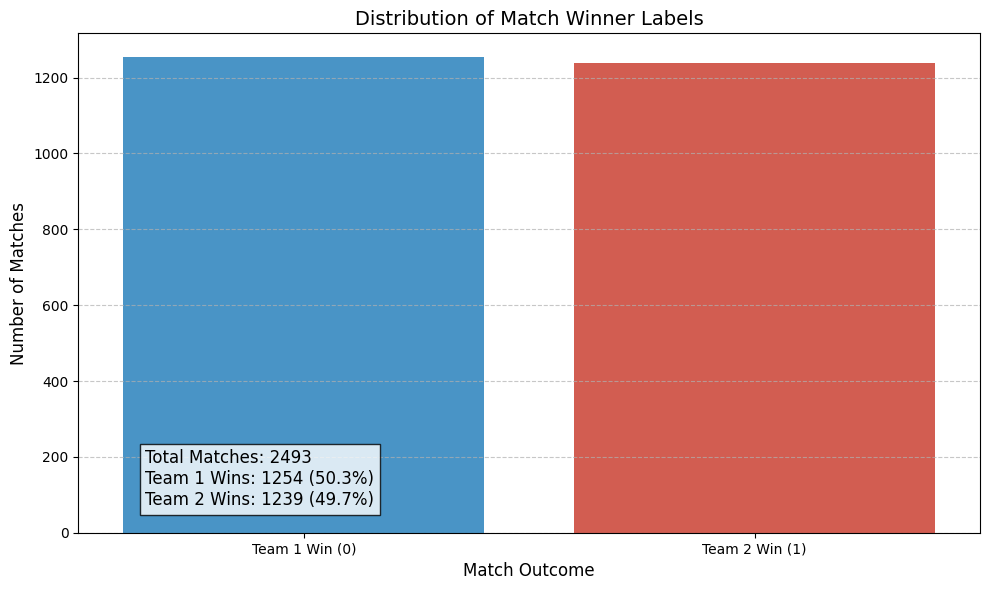

Total matches: 2493
Team 1 wins (0): 1254 (50.30%)
Team 2 wins (1): 1239 (49.70%)
Absolute difference: 15 matches (0.60%)


In [21]:
# Calculate the value counts for Match Winner Label
winner_counts = df["Match Winner Label"].value_counts().sort_index()

# Create a DataFrame for better visualization with seaborn
count_df = pd.DataFrame({
    'Winner': ['Team 1 Win (0)', 'Team 2 Win (1)'],
    'Count': winner_counts.values
})

# Calculate percentages for annotations
total = count_df['Count'].sum()
percentages = [f"{(count/total)*100:.1f}%" for count in count_df['Count']]

# Create the plot with improved styling
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Winner', y='Count', data=count_df, palette=['#3498db', '#e74c3c'])

# Add actual percentage difference as a title note
diff_percent = abs((winner_counts[0] - winner_counts[1]) / total * 100)
plt.title('Distribution of Match Winner Labels', fontsize=14)

# Customize the plot
plt.ylabel('Number of Matches', fontsize=12)
plt.xlabel('Match Outcome', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a text box with balance information
balance_text = f"Total Matches: {total}\nTeam 1 Wins: {winner_counts[0]} ({winner_counts[0]/total*100:.1f}%)\nTeam 2 Wins: {winner_counts[1]} ({winner_counts[1]/total*100:.1f}%)"
plt.figtext(0.15, 0.15, balance_text, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print statistical information for reference
print(f"Total matches: {total}")
print(f"Team 1 wins (0): {winner_counts[0]} ({winner_counts[0]/total*100:.2f}%)")
print(f"Team 2 wins (1): {winner_counts[1]} ({winner_counts[1]/total*100:.2f}%)")
print(f"Absolute difference: {abs(winner_counts[0] - winner_counts[1])} matches ({diff_percent:.2f}%)")

Randomly swap team 1 and team 2 to ensure ordering effects are limited

In [ ]:
# # Ensure reproducibility
# np.random.seed(42)

# # Copy your dataframe to avoid modifying original
# df_balanced = df.copy()

# # Get indices where Team1 is the winner (label 0)
# team1_wins = df_balanced[df_balanced["Match Winner Label"] == 0]

# # Calculate how many team1_wins to flip to get a 50/50 balance
# num_to_flip = len(team1_wins) - (len(df_balanced) // 2)

# # Randomly select indices to flip
# indices_to_flip = team1_wins.sample(n=num_to_flip).index

# # Flip team1 and team2, and change label from 0 → 1
# df_balanced.loc[indices_to_flip, ["Team1 ID", "Team2"]] = df_balanced.loc[indices_to_flip, ["Team2 ID", "Team1 ID"]].values
# df_balanced.loc[indices_to_flip, "Match Winner Label"] = 1

# # List of column pairs to swap
# team_columns = [
#     ("Team1 ID", "Team2 ID"),
#     ("Team1 Name", "Team2 Name"),
#     ("Team1 Captain", "Team2 Captain"),
#     ("Team1 Runs Scored", "Team2 Runs Scored"),
#     ("Team1 Wickets Fell", "Team2 Wickets Fell"),
#     ("Team1 Extras Rec", "Team2 Extras Rec"),
#     ("Team1 Playing 11", "Team2 Playing 11"),
#     ("Team1 Captain Win Rate", "Team2 Captain Win Rate"),
#     ("Team1 Captain Match Count", "Team2 Captain Match Count"),
#     ("Team1 Win Rate", "Team2 Win Rate"),
#     ("Team1 Head-to-Head Ratio", "Team2 Head-to-Head Ratio")
# ]

# # Flip all relevant columns
# for col1, col2 in team_columns:
#     df_balanced.loc[indices_to_flip, [col1, col2]] = df_balanced.loc[indices_to_flip, [col2, col1]].values

# # Flip label
# df_balanced.loc[indices_to_flip, "Match Winner Label"] = 1
# df_balanced.loc[indices_to_flip, "Home Country"] = 1 - df_balanced.loc[indices_to_flip, "Home Country"]

# Final Feature Selection

In [ ]:
correlation_df = df[['T20I Match No', 'Match ID', 'Series ID',  'Team1 ID', 'Team1 Captain', 'Team2 ID', 'Team2 Captain', 'Match Winner', 'Home Country', 'Team1 Win Rate', 'Team2 Win Rate',
       'Team1 Head-to-Head Ratio', 'Team2 Head-to-Head Ratio', "Team1 Captain Win Rate", "Team2 Captain Win Rate", "Team1 Captain Match Count", "Team2 Captain Match Count"]]

Chosen Features:

Team1 Win Rate

Team2 Win Rate

Team1 Head-to-Head Ratio

Team2 Head-to-Head Ratio

Home Country

Team1 Captain Win Rate

Team2 Captain Win Rate

Team1 Captain Match Count

Team2 Captain Match Count

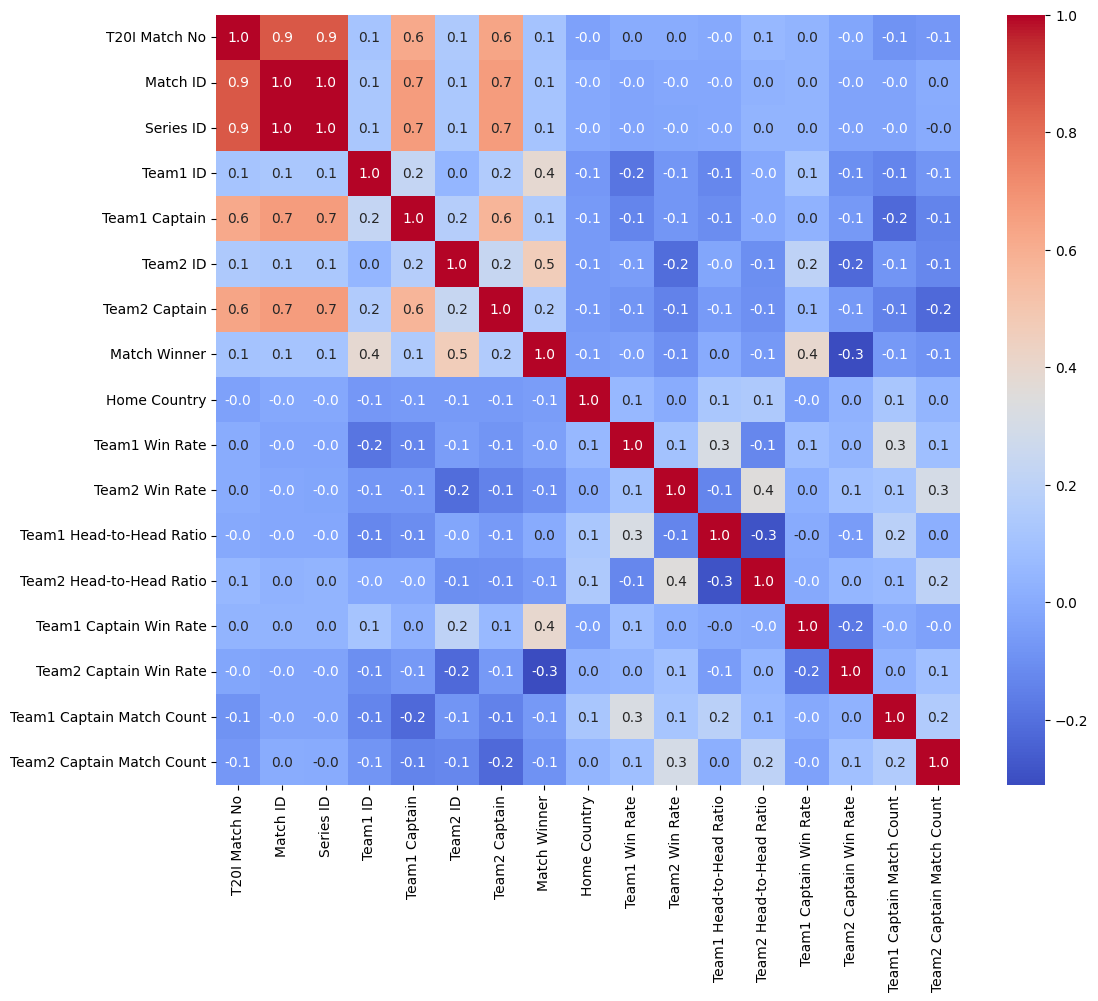

In [ ]:
corr = correlation_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot = True, cmap="coolwarm", fmt = '.1f')
plt.show()

## Reduce Complexity




In [ ]:
final_df = df[['Team1 ID', 'Team2 ID', 'Match Winner Label', "Home Country", "Team1 Win Rate", "Team2 Win Rate", "Team1 Head-to-Head Ratio",
         "Team2 Head-to-Head Ratio", "Team1 Captain Win Rate", "Team2 Captain Win Rate", "Team1 Captain Match Count", "Team2 Captain Match Count" ]]
final_df

,Team1 ID,Team2 ID,Match Winner Label,Home Country,Team1 Win Rate,Team2 Win Rate,Team1 Head-to-Head Ratio,Team2 Head-to-Head Ratio,Team1 Captain Win Rate,Team2 Captain Win Rate,Team1 Captain Match Count,Team2 Captain Match Count
0,1,2,1,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.470587,2.0,17.0
1,2,5,1,0.0,0.000000,0.000000,0.000000,0.000000,2.470587,-0.249999,17.0,4.0
2,3,5,0,1.0,0.000000,0.000000,0.000000,0.000000,0.259259,-0.249999,27.0,4.0
3,1,7,0,1.0,1.000000,0.000000,0.000000,0.000000,1.333329,-5.999940,3.0,1.0
4,8,1,1,0.0,0.000000,0.500000,0.000000,0.000000,0.666666,1.333329,18.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2523,207,142,1,0.0,0.300000,0.461538,0.500000,0.500000,-42.153814,1.300000,13.0,30.0
2524,207,142,0,0.0,0.322581,0.444444,0.666667,0.333333,-42.153814,1.300000,13.0,30.0
2525,142,207,1,1.0,0.464286,0.312500,0.500000,0.500000,1.300000,-42.153814,30.0,13.0
2526,207,142,1,0.0,0.303030,0.482759,0.400000,0.600000,-42.153814,1.300000,13.0,30.0


This
 augmentations did not improve performance

In [ ]:
# Swap Team1 and Team2 data
cols_to_swap = [
    ("Team1 ID", "Team2 ID"),
    ("Team1 Win Rate", "Team2 Win Rate"),
    ("Team1 Head-to-Head Ratio", "Team2 Head-to-Head Ratio"),
    ("Team1 Captain Win Rate", "Team2 Captain Win Rate"),
    ("Team1 Captain Match Count", "Team2 Captain Match Count")
]
df_swap = final_df.copy()
# Swap columns
for col1, col2 in cols_to_swap:
    df_swap[col1], df_swap[col2] = final_df[col2], final_df[col1]

# Swap Home Country (0 <-> 1)
df_swap["Home Country"] = final_df["Home Country"].apply(lambda x: 1 - x)
df_swap["Match Winner Label"] = final_df["Match Winner Label"].apply(lambda x: 1 - x)

# Combine original + swapped
df_augmented = pd.concat([final_df, df_swap], ignore_index=True)

In [ ]:
df_augmented["Win Rate Diff"] = df_augmented["Team1 Win Rate"] - df_augmented["Team2 Win Rate"]
df_augmented["Captain Win Rate Diff"] = df_augmented["Team1 Captain Win Rate"] - df_augmented["Team2 Captain Win Rate"]
df_augmented["Captain Match Count Diff"] = df_augmented["Team1 Captain Match Count"] - df_augmented["Team2 Captain Match Count"]
df_augmented["Head-to-Head Diff"] = df_augmented["Team1 Head-to-Head Ratio"] - df_augmented["Team2 Head-to-Head Ratio"]
df_augmented = df_augmented[['Match Winner Label', "Home Country", "Captain Win Rate Diff",  "Win Rate Diff", "Captain Match Count Diff", "Head-to-Head Diff"]]

#Data Anlysis

Histogram:
- Teams and their number of entries
- Teams and their number of wins

In [ ]:
##gonna add, just don't have time currently
##Thinking it'll help with analysis of our data
#Im thinking there might be more entries for one team than another looking at
##that one kaggle user's work
##Can explain why our model preforms with its metrics
counts = final_df["Match Winner Label"].value_counts()
ratio = counts[0] / counts[1]
print("Ratio of 0 wins to 1 wins:", ratio)

Ratio of 0 wins to 1 wins: 1.0121065375302662


# Naive Baseline 1: Home Team Wins


In [ ]:
def home_country_accuracy(X, y):
    """
    Computes the accuracy of predicting the match winner as the home country.

    Parameters:
    X (pd.Series): Series of home countries.
    y (pd.Series): Series of actual match winner labels (must be strings or categories).

    Returns:
    float: Accuracy of the home country prediction.
    """
    predictions = X
    correct = (predictions == y).sum()
    total = len(y)
    accuracy = correct / total
    return accuracy

In [ ]:
X = final_df["Home Country"] # Predict
y = final_df["Match Winner Label"] # Labels

In [ ]:
print(home_country_accuracy(X, y))

0.2988367428800642


# Naive Baseline 2: Team 1 Wins

In [ ]:
correct = (y == 0).sum()
total = len(y)
accuracy = correct / total
accuracy

np.float64(0.5030084235860409)

# Feed Forward Neural Network


## Imports


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

## Helper Functions


In [ ]:
def train(model,  data_generator, loss_function, optimizer):
  model.train() #updates any model layers that behave differently in training and execution
  avg_loss = 0
  num_batches = 0
  for i, (input_data, target_output) in enumerate(data_generator):
    optimizer.zero_grad()                            # Gradients need to be reset each batch
    prediction = model(input_data)                 # Forward pass: compute the output class given a image
    loss = loss_function(prediction, target_output)  # Compute the loss: difference between the output and correct result
    loss.backward()                                  # Backward pass: compute the gradients of the model with respect to the loss
    optimizer.step()
    avg_loss += loss.item()
    num_batches += 1
  return avg_loss/num_batches

In [ ]:
def test(model, test_loader, loss_function):
    model.eval()
    test_loss = 0.0
    num_batches = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += loss_function(output, target).item()
            # Binary prediction
            pred = (torch.sigmoid(output) > 0.5).float()  # If using BCEWithLogitsLoss
            # Optional: compare with target to compute accuracy, etc.
            num_batches += 1
    test_loss /= num_batches
    return test_loss

In [ ]:
def logResults(epoch, num_epochs, train_loss, train_loss_history, test_loss, test_loss_history, epoch_counter, print_interval=1000):
  if (epoch%print_interval == 0):  print('Epoch [%d/%d], Train Loss: %.4f, Test Loss: %.4f' %(epoch+1, num_epochs, train_loss, test_loss))
  train_loss_history.append(train_loss)
  test_loss_history.append(test_loss)
  epoch_counter.append(epoch)

In [ ]:
def graphLoss(epoch_counter, train_loss_hist, test_loss_hist, loss_name="Loss", start = 0):
  fig = plt.figure()
  plt.plot(epoch_counter[start:], train_loss_hist[start:], color='blue')
  plt.plot(epoch_counter[start:], test_loss_hist[start:], color='red')
  plt.legend(['Train Loss', 'Test Loss'], loc='upper right')
  plt.xlabel('#Epochs')
  plt.ylabel(loss_name)

In [ ]:
def trainAndGraph(model, training_generator, testing_generator, loss_function, optimizer, num_epochs, learning_rate, logging_interval=1):
  #Arrays to store training history
  test_loss_history = []
  epoch_counter = []
  train_loss_history = []

  for epoch in range(num_epochs):
    avg_loss = train(model, training_generator, loss_function, optimizer)
    test_loss = test(model, testing_generator, loss_function)
    logResults(epoch, num_epochs, avg_loss, train_loss_history, test_loss, test_loss_history, epoch_counter, logging_interval)

  graphLoss(epoch_counter, train_loss_history, test_loss_history)

## The model

In [ ]:
class WinPredictor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.linear1 = nn.Linear(input_size, 64)
        self.linear2 = nn.Linear(64, 32)
        self.linear3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.linear1(x)
        x = F.relu(x)
        x = self.linear2(x)
        x = F.relu(x)
        x = self.linear3(x)

        return x.squeeze(1)

## Data Split and Normalization

In [ ]:
class DataFrameDataset(Dataset):
    def __init__(self, X_df, y_series):
        self.X = torch.tensor(X_df.values, dtype=torch.float32)
        self.y = torch.tensor(y_series.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
X = final_df.drop('Match Winner Label', axis=1) # Features
X = X.drop("Team1 ID", axis=1)
X = X.drop("Team2 ID", axis=1)

y = final_df["Match Winner Label"] # Labels

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
s1 = StandardScaler()
s2 = StandardScaler()

# x_train["Captain Match Count Diff"] = scaler.fit_transform(x_train[["Captain Match Count Diff"]])
# # x_test["Captain Match Count Diff"] = scaler.transform(x_test[["Captain Match Count Diff"]])
x_train["Team2 Captain Match Count"] = s1.fit_transform(x_train[["Team2 Captain Match Count"]])
x_test["Team2 Captain Match Count"] = s1.transform(x_test[["Team2 Captain Match Count"]])

x_train["Team1 Captain Match Count"] = s2.fit_transform(x_train[["Team1 Captain Match Count"]])
x_test["Team1 Captain Match Count"] = s2.transform(x_test[["Team1 Captain Match Count"]])

In [ ]:
train_dataset = DataFrameDataset(x_train, y_train)
test_dataset = DataFrameDataset(x_test, y_test)

## Train Once

Loaded Data
Epoch [1/70], Train Loss: 1.5731, Test Loss: 0.8281
Epoch [16/70], Train Loss: 0.6744, Test Loss: 0.6721
Epoch [31/70], Train Loss: 0.6574, Test Loss: 0.6542
Epoch [46/70], Train Loss: 0.6387, Test Loss: 0.6866
Epoch [61/70], Train Loss: 0.6338, Test Loss: 0.6485


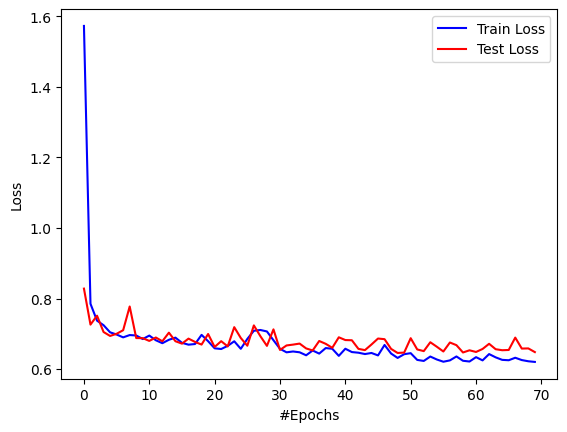

In [ ]:
#Training parameters
num_epochs = 70
print_interval = 15
learning_rate = 0.001
batch_size = 200
input_size = len(X.columns)

# #Create model
predModel = WinPredictor(input_size)

#Set optimizer and loss function
model = predModel;
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_function = nn.BCEWithLogitsLoss()

#Load the data, and split it into batches
training_generator = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
testing_generator = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size)

print("Loaded Data")

trainAndGraph(model, training_generator, testing_generator, loss_function, optimizer, num_epochs, learning_rate, print_interval)

In [ ]:
print(len(X.columns))

9


## Evaluate Performance Train







AUC: 0.7243280250067154
Precision [0.61218425 0.72376543]
Recall [0.82153539 0.47325933]
F1 [0.70157514 0.57230018]
Count [1003  991]


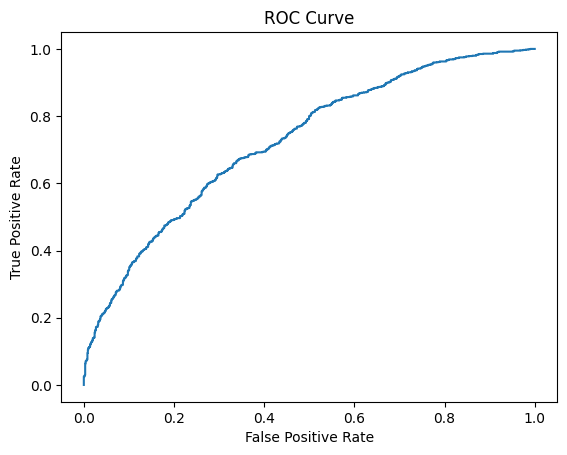

In [ ]:
preds = model(torch.tensor(x_train.to_numpy()).float()).detach().numpy()
fpr, tpr, thresholds = metrics.roc_curve(y_train.to_numpy(),preds)
plt.plot(fpr,tpr)
plt.title("ROC Curve")
print("AUC:",metrics.auc(fpr, tpr))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
p,r,f,count = metrics.precision_recall_fscore_support(y_train.to_numpy(),preds>0.3)
print("Precision",p)
print("Recall",r)
print("F1",f)
print("Count",count)

Based on the ROC curve

In [ ]:
y_pred_class = (preds > 0.3).astype(int)
cm = confusion_matrix(y_train, y_pred_class)
cm

array([[824, 179],
       [522, 469]])

In [ ]:
class_report = classification_report(y_train, y_pred_class)
class_report

'              precision    recall  f1-score   support\n\n           0       0.61      0.82      0.70      1003\n           1       0.72      0.47      0.57       991\n\n    accuracy                           0.65      1994\n   macro avg       0.67      0.65      0.64      1994\nweighted avg       0.67      0.65      0.64      1994\n'

## Evaluate Performance: Test

AUC: 0.6858533607505461
Count [251 248]


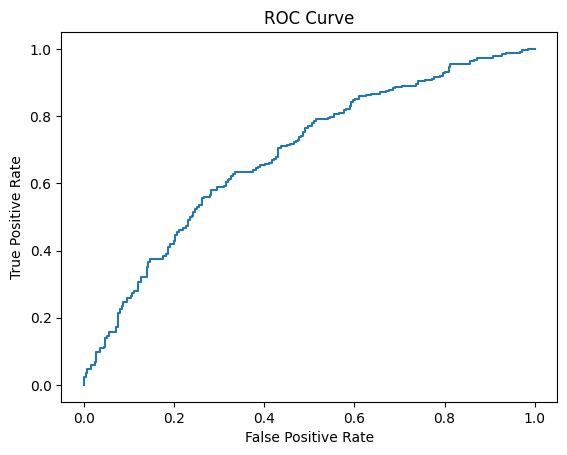

In [ ]:
preds = model(torch.tensor(x_test.to_numpy()).float()).detach().numpy()
fpr, tpr, thresholds = metrics.roc_curve(y_test.to_numpy(),preds)
plt.plot(fpr,tpr)
plt.title("ROC Curve")
print("AUC:",metrics.auc(fpr, tpr))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
p,r,f,count = metrics.precision_recall_fscore_support(y_test.to_numpy(),preds>0.3)
print("Count",count)

In [ ]:
y_pred_class = (preds > 0.3).astype(int)
cm = confusion_matrix(y_test, y_pred_class)
cm

array([[196,  55],
       [133, 115]])

In [ ]:
class_report = classification_report(y_test, y_pred_class)
class_report

'              precision    recall  f1-score   support\n\n           0       0.60      0.78      0.68       251\n           1       0.68      0.46      0.55       248\n\n    accuracy                           0.62       499\n   macro avg       0.64      0.62      0.61       499\nweighted avg       0.64      0.62      0.61       499\n'

#Random Forest

##Imports

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.tree import export_graphviz
import graphviz

Generating train and testing splits

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Creating and Tuning Model

In [ ]:
rf = RandomForestClassifier(random_state=42) #making classifier, set to be reproducable

#Using random search to find best hyperparameters
random_search = RandomizedSearchCV(estimator = rf, param_distributions =
              {'n_estimators': randint(50, 500), 'max_depth': randint(1, 20), 'min_samples_split': randint(2, 20), 'min_samples_leaf': randint(1, 20)},
                                   n_iter= 5,
                                   cv=5)

#using training data in previous model
random_search.fit(x_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=5,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a2e03647ed0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a2cd9eb0d90>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a2cd9e55810>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a2cd9e1e8d0>})

In [ ]:
#setting varaible for best model
best_random_forest = random_search.best_estimator_

print("Best Hyper Parameters: ",  random_search.best_params_)

Best Hyper Parameters:  {'max_depth': 16, 'min_samples_leaf': 17, 'min_samples_split': 12, 'n_estimators': 143}


#Testing

In [ ]:
y_pred = best_random_forest.predict(x_test)

#Evaluation

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cross_val_scores = cross_val_score(best_random_forest, X, y, cv=5)

print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-score: ", f1)
print("Cross-Validation Scores: ", cross_val_scores)
print("Mean Cross-Validation Score: ", cross_val_scores.mean())

Accuracy:  0.6412825651302605
Precision:  0.6455696202531646
Recall:  0.6169354838709677
F1-score:  0.6309278350515464
Cross-Validation Scores:  [0.56112224 0.61923848 0.65330661 0.69076305 0.60240964]
Mean Cross-Validation Score:  0.6253680050864782


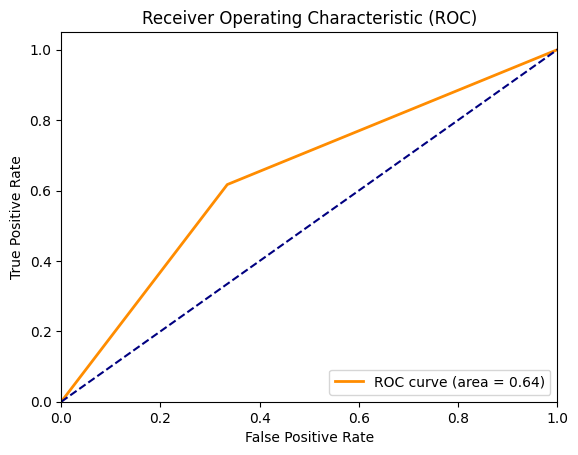

AUC:  0.6411370646446473


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc(fpr, tpr))
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

print(f"AUC: ", roc_auc)

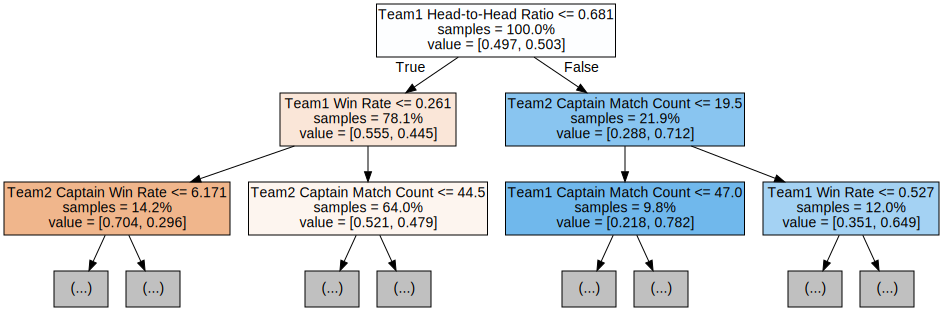

In [ ]:
for i in range(1):
  tree= best_random_forest.estimators_[i]
  data = export_graphviz(tree, feature_names = x_train.columns, filled = True,
                         max_depth = 2, impurity=False, proportion=True)
  graph = graphviz.Source(data)
  display(graph)